In [1]:
from io import StringIO
import json
import os

import boto3
import pandas as pd
pd.set_option("display.max_columns", 50)

In [2]:
aws_access_key = os.getenv("AWS_ACCESS_KEY")
aws_secret_key = os.getenv("AWS_SECRET_KEY")

In [3]:
s3 = boto3.client("s3", aws_access_key_id=aws_access_key, aws_secret_access_key=aws_secret_key)

In [4]:
bucket = "cubix-chicago-taxi-bb-v2"

dim_community_areas_path = "transformed_data/dim_community_areas/dim_community_areas.csv"
dim_company_path = "transformed_data/dim_company/dim_company.csv"
dim_date_path = "transformed_data/dim_date/dim_date.csv"
dim_payment_type_path = "transformed_data/dim_payment_type/dim_payment_type.csv"
dim_weather_path = "transformed_data/dim_weather/"
fact_taxi_trips_path = "transformed_data/fact_taxi_trips/"

In [5]:
def read_file_from_s3(
    s3,
    bucket: str,
    key: str,
    file_format: str = "csv"
):
    """
    Reads a csv or json file from the given S3 bucket.

    :param s3:          S3 client.
    :param bucket:      Name of the S3 Bucket where the file is stored.
    :param key:         Path within the S3 bucket.
    :param file_format: "json" or "csv".
    """
    respone = s3.get_object(Bucket=bucket, Key=key)
    content = respone["Body"].read().decode("utf-8")

    if file_format == "csv":
        return pd.read_csv(StringIO(content))
    elif file_format == "json":
        return json.loads(content)
    else:
        raise ValueError("Unsupported file format, use 'csv' or 'json'.")

In [6]:
dim_community_areas = read_file_from_s3(s3, bucket, dim_community_areas_path)
dim_company         = read_file_from_s3(s3, bucket, dim_company_path)
dim_date            = read_file_from_s3(s3, bucket, dim_date_path)
dim_payment_type    = read_file_from_s3(s3, bucket, dim_payment_type_path)

In [7]:
print(dim_community_areas.head(1))
print(dim_company.head(1))
print(dim_date.head(1))
print(dim_payment_type.head(1))

   area_code community_area
0          1    Rogers Park
   company_id     company
0           1  Globe Taxi
         date  year  month  day  day_of_week  is_weekend
0  2025-01-01  2025      1    1            3       False
   payment_type_id payment_type
0                1       Prcard


In [8]:
fact_taxi_trips_list = []
dim_weather_list = []

In [9]:
for file in s3.list_objects(Bucket=bucket, Prefix=fact_taxi_trips_path)["Contents"]:
    taxi_key = file["Key"]
    taxi_raw_file_name = file["Key"].split("/")[-1]
    
    if taxi_raw_file_name.split(".")[-1] == "csv":
        daily_file_name = fact_taxi_trips_path + taxi_raw_file_name
        taxi_trip_daily = read_file_from_s3(s3, bucket, daily_file_name)

        fact_taxi_trips_list.append(taxi_trip_daily)
        print(f"{taxi_raw_file_name} has been added")

taxi_2025-07-24.csv has been added
taxi_2025-08-03.csv has been added
taxi_2025-08-04.csv has been added
taxi_2025-08-05.csv has been added
taxi_2025-08-06.csv has been added
taxi_2025-08-07.csv has been added
taxi_2025-08-08.csv has been added
taxi_2025-08-09.csv has been added
taxi_2025-08-10.csv has been added
taxi_2025-08-11.csv has been added
taxi_2025-08-12.csv has been added
taxi_2025-08-13.csv has been added
taxi_2025-08-14.csv has been added
taxi_2025-08-15.csv has been added
taxi_2025-08-16.csv has been added
taxi_2025-08-17.csv has been added
taxi_2025-08-18.csv has been added
taxi_2025-08-19.csv has been added
taxi_2025-08-20.csv has been added
taxi_2025-08-21.csv has been added
taxi_2025-08-22.csv has been added
taxi_2025-08-23.csv has been added
taxi_2025-08-24.csv has been added
taxi_2025-08-25.csv has been added
taxi_2025-08-26.csv has been added
taxi_2025-08-27.csv has been added
taxi_2025-08-28.csv has been added
taxi_2025-08-29.csv has been added
taxi_2025-08-30.csv 

In [10]:
fact_taxi_trips_list

[                                        trip_id  \
 0      010fa2075ff11e11fba59c1b3bad15496fdf828c   
 1      ffbba4a953e15a34f3d3438be6497ed5dcd7b097   
 2      fdc4f0f46fb4734a03e66576f9d1b01fc1fb2ff9   
 3      fb111806c65b4f40bb47e7dfa5ff449c5b66941b   
 4      fa127a2bac37ec154bb69f999ac87d5dc562d486   
 ...                                         ...   
 19893  624ce6ab1987dab1c0986aa129a404f4f52c3a5d   
 19894  2fcef5eef1ff6bae6712712783fd22d17f244462   
 19895  6946c1cd38aeea910ff997db8b7bedb446692523   
 19896  6965f3d24effebff9f5718d12dd73c9e7c5e65c9   
 19897  7406d8c7120d3199d26b068984f5e1db3183f1d6   
 
                                                  taxi_id trip_start_timestamp  \
 0      661cda59f0dc5cacf442f48593e300010c8f10a4a6d0e0...  2025-07-24 23:45:00   
 1      356744753023949fa63be6a6d7e0aef31f2d50dd3b0258...  2025-07-24 23:45:00   
 2      adb1cb74113851b651b474182fbe95a9663783779db8cc...  2025-07-24 23:45:00   
 3      db39bc53c7204111f0786edff94251c636dcce

In [11]:
fact_taxi_trips = pd.concat(fact_taxi_trips_list, ignore_index=True)

In [12]:
fact_taxi_trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3131808 entries, 0 to 3131807
Data columns (total 20 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   trip_id                     object 
 1   taxi_id                     object 
 2   trip_start_timestamp        object 
 3   trip_end_timestamp          object 
 4   trip_seconds                int64  
 5   trip_miles                  float64
 6   pickup_community_area_id    int64  
 7   dropoff_community_area_id   int64  
 8   fare                        float64
 9   tips                        float64
 10  tolls                       float64
 11  extras                      float64
 12  trip_total                  float64
 13  pickup_centroid_latitude    float64
 14  pickup_centroid_longitude   float64
 15  dropoff_centroid_latitude   float64
 16  dropoff_centroid_longitude  float64
 17  datetime_for_weather        object 
 18  payment_type_id             int64  
 19  company_id           

In [13]:
for file in s3.list_objects(Bucket=bucket, Prefix=dim_weather_path)["Contents"]:
    weather_key = file["Key"]
    weather_raw_file_name = file["Key"].split("/")[-1]
    
    if weather_raw_file_name.split(".")[-1] == "csv":
        daily_file_name = dim_weather_path + weather_raw_file_name
        weather_daily = read_file_from_s3(s3, bucket, daily_file_name)

        dim_weather_list.append(weather_daily)
        print(f"{weather_raw_file_name} has been added")

weather_2025-07-24.csv has been added
weather_2025-08-03.csv has been added
weather_2025-08-04.csv has been added
weather_2025-08-05.csv has been added
weather_2025-08-06.csv has been added
weather_2025-08-07.csv has been added
weather_2025-08-08.csv has been added
weather_2025-08-09.csv has been added
weather_2025-08-10.csv has been added
weather_2025-08-11.csv has been added
weather_2025-08-12.csv has been added
weather_2025-08-13.csv has been added
weather_2025-08-14.csv has been added
weather_2025-08-15.csv has been added
weather_2025-08-16.csv has been added
weather_2025-08-17.csv has been added
weather_2025-08-18.csv has been added
weather_2025-08-19.csv has been added
weather_2025-08-20.csv has been added
weather_2025-08-21.csv has been added
weather_2025-08-22.csv has been added
weather_2025-08-23.csv has been added
weather_2025-08-24.csv has been added
weather_2025-08-25.csv has been added
weather_2025-08-26.csv has been added
weather_2025-08-27.csv has been added
weather_2025

In [14]:
dim_weather = pd.concat(dim_weather_list, ignore_index=True)

In [15]:
dim_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4512 entries, 0 to 4511
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   datetime       4512 non-null   object 
 1   temperature    4512 non-null   float64
 2   wind_speed     4512 non-null   float64
 3   rain           4512 non-null   float64
 4   precipitation  4512 non-null   float64
dtypes: float64(4), object(1)
memory usage: 176.4+ KB


#### Create datamodel

In [16]:
fact_taxi_trips_full = pd.merge(fact_taxi_trips, dim_weather, left_on="datetime_for_weather", right_on="datetime")
fact_taxi_trips_full = fact_taxi_trips_full.drop(columns=["datetime", "datetime_for_weather"])

fact_taxi_trips_full.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_community_area_id,dropoff_community_area_id,fare,tips,tolls,extras,trip_total,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude,payment_type_id,company_id,temperature,wind_speed,rain,precipitation
0,010fa2075ff11e11fba59c1b3bad15496fdf828c,661cda59f0dc5cacf442f48593e300010c8f10a4a6d0e0...,2025-07-24 23:45:00,2025-07-25T00:00:00.000,1168,17.56,76,8,75.50,15.20,0.0,0.0,91.20,41.980264,-87.913625,41.899602,-87.633308,2,6,29.9,10.8,0.2,0.2
1,ffbba4a953e15a34f3d3438be6497ed5dcd7b097,356744753023949fa63be6a6d7e0aef31f2d50dd3b0258...,2025-07-24 23:45:00,2025-07-25T00:15:00.000,1097,10.63,2,33,27.75,4.24,0.0,0.0,31.99,42.001571,-87.695013,41.857184,-87.620335,1,4,29.9,10.8,0.2,0.2
2,fdc4f0f46fb4734a03e66576f9d1b01fc1fb2ff9,adb1cb74113851b651b474182fbe95a9663783779db8cc...,2025-07-24 23:45:00,2025-07-25T00:00:00.000,1037,12.20,36,77,30.75,0.00,0.0,0.0,30.75,41.823713,-87.602350,41.986712,-87.663416,1,7,29.9,10.8,0.2,0.2
3,fb111806c65b4f40bb47e7dfa5ff449c5b66941b,db39bc53c7204111f0786edff94251c636dcce5fec8dbe...,2025-07-24 23:45:00,2025-07-25T00:15:00.000,1500,10.00,56,75,26.75,0.00,0.0,4.0,30.75,41.792592,-87.769615,41.689730,-87.669054,3,2,29.9,10.8,0.2,0.2
4,fa127a2bac37ec154bb69f999ac87d5dc562d486,5732bb53e9becb096e11b52228bb5079a585622bd15b74...,2025-07-24 23:45:00,2025-07-25T00:00:00.000,1200,11.00,76,16,29.00,6.70,0.0,4.0,39.70,41.980264,-87.913625,41.953582,-87.723452,2,2,29.9,10.8,0.2,0.2


In [17]:
fact_taxi_trips_full = pd.merge(fact_taxi_trips_full, dim_company, left_on="company_id", right_on="company_id")
fact_taxi_trips_full = fact_taxi_trips_full.drop(columns=["company_id"])

In [18]:
fact_taxi_trips_full = pd.merge(fact_taxi_trips_full, dim_payment_type, left_on="payment_type_id", right_on="payment_type_id")
fact_taxi_trips_full = fact_taxi_trips_full.drop(columns=["payment_type_id"])

In [19]:
fact_taxi_trips_full = pd.merge(fact_taxi_trips_full, dim_community_areas, left_on="pickup_community_area_id", right_on="area_code")
fact_taxi_trips_full = fact_taxi_trips_full.drop(columns=["pickup_community_area_id", "area_code"])
fact_taxi_trips_full.rename(columns={"community_area": "pickup_community_area_name"}, inplace=True)

In [20]:
fact_taxi_trips_full = pd.merge(fact_taxi_trips_full, dim_community_areas, left_on="dropoff_community_area_id", right_on="area_code")
fact_taxi_trips_full = fact_taxi_trips_full.drop(columns=["dropoff_community_area_id", "area_code"])
fact_taxi_trips_full.rename(columns={"community_area": "dropoff_community_area_name"}, inplace=True)

In [21]:
dim_date["date"] = pd.to_datetime(dim_date["date"])
fact_taxi_trips_full["trip_start_timestamp"] = pd.to_datetime(fact_taxi_trips_full["trip_start_timestamp"])

fact_taxi_trips_full["trip_start_date"] = pd.to_datetime(fact_taxi_trips_full["trip_start_timestamp"].dt.date)

In [22]:
fact_taxi_trips_full = pd.merge(fact_taxi_trips_full, dim_date, left_on="trip_start_date", right_on="date")
fact_taxi_trips_full = fact_taxi_trips_full.drop(columns=["trip_start_date", "date"])

In [23]:
fact_taxi_trips_full.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,fare,tips,tolls,extras,trip_total,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude,temperature,wind_speed,rain,precipitation,company,payment_type,pickup_community_area_name,dropoff_community_area_name,year,month,day,day_of_week,is_weekend
0,010fa2075ff11e11fba59c1b3bad15496fdf828c,661cda59f0dc5cacf442f48593e300010c8f10a4a6d0e0...,2025-07-24 23:45:00,2025-07-25T00:00:00.000,1168,17.56,75.50,15.20,0.0,0.0,91.20,41.980264,-87.913625,41.899602,-87.633308,29.9,10.8,0.2,0.2,Sun Taxi,Credit Card,O'Hare,Near North Side,2025,7,24,4,False
1,ffbba4a953e15a34f3d3438be6497ed5dcd7b097,356744753023949fa63be6a6d7e0aef31f2d50dd3b0258...,2025-07-24 23:45:00,2025-07-25T00:15:00.000,1097,10.63,27.75,4.24,0.0,0.0,31.99,42.001571,-87.695013,41.857184,-87.620335,29.9,10.8,0.2,0.2,Flash Cab,Prcard,West Ridge,Near South Side,2025,7,24,4,False
2,fdc4f0f46fb4734a03e66576f9d1b01fc1fb2ff9,adb1cb74113851b651b474182fbe95a9663783779db8cc...,2025-07-24 23:45:00,2025-07-25T00:00:00.000,1037,12.20,30.75,0.00,0.0,0.0,30.75,41.823713,-87.602350,41.986712,-87.663416,29.9,10.8,0.2,0.2,5 Star Taxi,Prcard,Oakland,Edgewater,2025,7,24,4,False
3,fb111806c65b4f40bb47e7dfa5ff449c5b66941b,db39bc53c7204111f0786edff94251c636dcce5fec8dbe...,2025-07-24 23:45:00,2025-07-25T00:15:00.000,1500,10.00,26.75,0.00,0.0,4.0,30.75,41.792592,-87.769615,41.689730,-87.669054,29.9,10.8,0.2,0.2,Transit Administrative Center Inc,Cash,Garfield Ridge,Morgan Park,2025,7,24,4,False
4,fa127a2bac37ec154bb69f999ac87d5dc562d486,5732bb53e9becb096e11b52228bb5079a585622bd15b74...,2025-07-24 23:45:00,2025-07-25T00:00:00.000,1200,11.00,29.00,6.70,0.0,4.0,39.70,41.980264,-87.913625,41.953582,-87.723452,29.9,10.8,0.2,0.2,Transit Administrative Center Inc,Credit Card,O'Hare,Irving Park,2025,7,24,4,False


#### Seaborn test

In [27]:
import seaborn as sns

<Axes: xlabel='flipper_length_mm', ylabel='Count'>

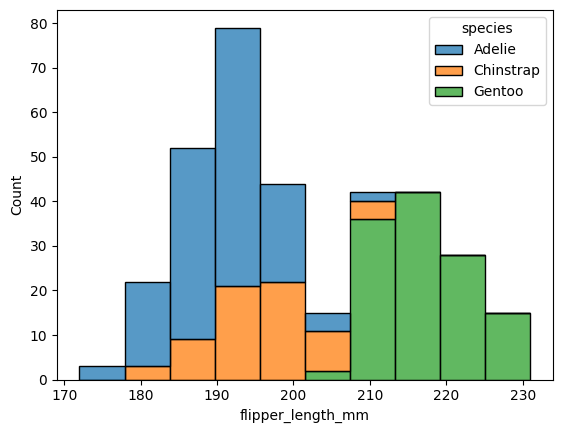

In [28]:
penguins = sns.load_dataset("penguins")
sns.histplot(data=penguins, x="flipper_length_mm", hue="species", multiple="stack")

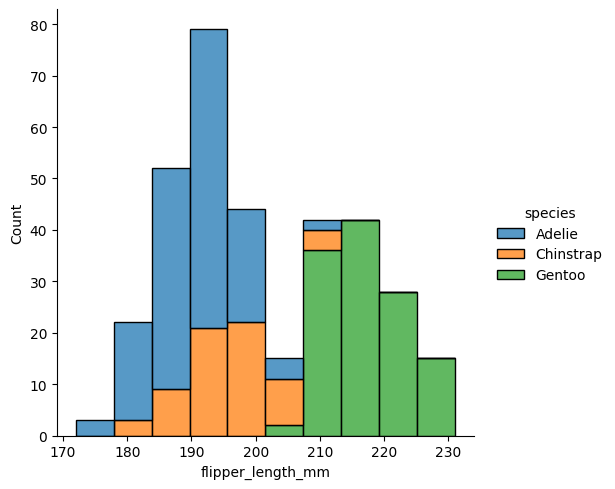

In [29]:
sns.displot(data=penguins, x="flipper_length_mm", hue="species", multiple="stack")

In [ ]:
import matplotlib.pyplot as plt